# Flow Matching: Parameter Estimation

Series reaction A → B → C in a plug flow reactor.

Given observed exit concentrations, estimate the rate constants $k_1$ and $k_2$.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 14:25:06
Initial memory usage: 322.30 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
from scipy.integrate import solve_ivp

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Problem Setup

Series reactions in a PFR:
$$A \xrightarrow{k_1} B \xrightarrow{k_2} C$$

Governing ODEs:
$$\frac{dF_A}{dV} = -k_1 F_A / \nu$$
$$\frac{dF_B}{dV} = k_1 F_A / \nu - k_2 F_B / \nu$$

Given observed exit flows $(F_A, F_B)$, find $(k_1, k_2)$.

In [3]:
nu = 1
Vf = 2
F0 = [1, 0]

def ode(V, F, k1, k2):
    Fa, Fb = F
    dFadV = -k1 * Fa / nu
    dFbdV = k1 * Fa / nu - k2 * Fb / nu
    return dFadV, dFbdV

In [4]:
# Generate data
bounds = [[0.1, 3], [0.1, 3]]
K = generate_samples(bounds, n_samples=256, seed=42)

data = []
for k1, k2 in K:
    sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=(k1, k2))
    Fa, Fb = sol.y[:, -1]
    data.append([k1, k2, Fa, Fb])

data = np.array(data)
print(f"Data shape: {data.shape}")

Data shape: (256, 4)


In [5]:
# Train: generate [k1, k2] conditioned on [Fa, Fb]
x_data = data[:, :2]  # k1, k2
c_data = data[:, 2:]  # Fa, Fb

fm_param = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_param.fit(x_data, c_data, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [6]:
# Estimate parameters for two scenarios
observations = [[0.02, 0.05],  # low Fa, low Fb
                [0.02, 0.65]]  # low Fa, high Fb

for i, obs in enumerate(observations):
    samples = fm_param.sample(c_values=[obs], n_samples=500)
    k_est = samples.mean(axis=0)
    k_std = samples.std(axis=0)
    
    # Verify
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k_est[0], k_est[1])).y[:, -1]
    
    print(f"Scenario {i+1}: Target Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"  Estimated k1 = {k_est[0]:.3f} ± {k_std[0]:.3f}")
    print(f"  Estimated k2 = {k_est[1]:.3f} ± {k_std[1]:.3f}")
    print(f"  Actual: Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")
    print()

Scenario 1: Target Fa=0.020, Fb=0.050
  Estimated k1 = 1.939 ± 0.079
  Estimated k2 = 2.460 ± 0.100
  Actual: Fa=0.021, Fb=0.050

Scenario 2: Target Fa=0.020, Fb=0.650
  Estimated k1 = 2.001 ± 0.099
  Estimated k2 = 0.278 ± 0.066
  Actual: Fa=0.018, Fb=0.644



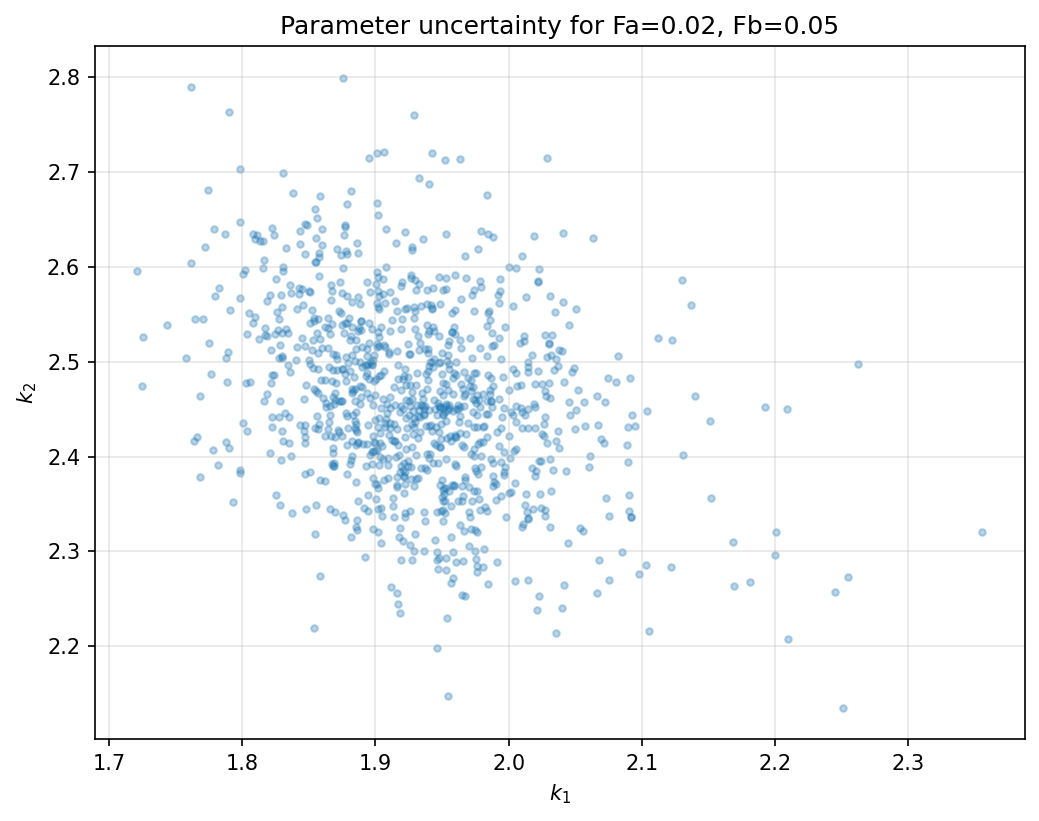

In [7]:
# Visualize uncertainty
samples = fm_param.sample(c_values=[[0.02, 0.05]], n_samples=1000)

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10)
plt.xlabel('$k_1$')
plt.ylabel('$k_2$')
plt.title('Parameter uncertainty for Fa=0.02, Fb=0.05')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 14:25:06
End time:        2025-12-18 14:25:09
Elapsed time:    3.58 seconds (0.06 minutes)
----------------------------------------------------------------------
Initial memory:  322.30 MB
Final memory:    438.55 MB
Memory change:   +116.25 MB
